# Plot Hessian analysis from `runs.db`

Reads the SQLite results store at `experiments/outputs/runs.db` (schema in `experiments/results.py`).

Two plot families:

1. **Metric bar plots**  per `(run_id, model_id, epoch)`, mirroring `plot_results.py` but pulling rows from the `metrics` table instead of a `results.json`.
2. **Spearman correlation of influence vectors**  loads the `.npy` files registered in the `influence` table and computes Spearman rank correlation against a reference approximator. Handles both the legacy 1D `(n_train,)` cache and the current 2D `(n_query, n_train)` matrices.

All plotting helpers require `run_id`, `model_id`, and `epoch` so the cells stay deterministic when the DB grows.

## Imports

In [23]:
# =====================================================================
# Setup — run once, then collapse this cell.
# Imports, constants, and every helper used by the cells below.
# =====================================================================
from __future__ import annotations

import json
import sqlite3
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from scipy.stats import rankdata

DB_PATH = Path("/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/runs.db")

# ── Style ────────────────────────────────────────────────────────────
COLORS = {
    "kfac": "#1f77b4",
    "ekfac": "#ff7f0e",
    "gnh": "#d62728",
    "fim": "#2ca02c",
    "block_fim": "#9467bd",
    "block_hessian": "#8c564b",
    "shampoo": "#e377c2",
    "eshampoo": "#7f7f7f",
    "identity": "#17becf",
    "exact": "#bcbd22",
}
LABELS = {
    "kfac": "K-FAC",
    "ekfac": "EK-FAC",
    "gnh": "GNH",
    "fim": "FIM",
    "block_fim": "Block FIM",
    "block_hessian": "Block Hessian",
    "shampoo": "Shampoo",
    "eshampoo": "E-Shampoo",
    "identity": "Identity",
    "exact": "Exact",
}
APPROX_ORDER = [
    "gnh",
    "fim",
    "block_hessian",
    "block_fim",
    "shampoo",
    "eshampoo",
    "ekfac",
    "kfac",
    "identity",
]
CATEGORY_DISPLAY = {
    "matrix": "Matrix",
    "hvp": "HVP",
    "ihvp": "IHVP",
    "round_trip": "Round-trip",
}

plt.rcParams.update({"font.size": 11})


# ── DB access ────────────────────────────────────────────────────────
def open_db(path: Path = DB_PATH) -> sqlite3.Connection:
    if not path.exists():
        raise FileNotFoundError(f"runs.db not found at {path}")
    return sqlite3.connect(str(path))


def load_runs_db(db_path: Path = DB_PATH) -> pd.DataFrame:
    """Return the whole runs.db as one analysis-ready DataFrame.

    One row per metric value, with `metrics` left-joined onto `results` and
    `runs`. Influence `.npy` paths live in their own table; use
    `load_influence_paths(con, run_id, model_id, epoch)` for those.
    """
    with open_db(db_path) as con:
        runs = pd.read_sql_query("SELECT * FROM runs", con)
        results = pd.read_sql_query("SELECT * FROM results", con)
        metrics = pd.read_sql_query("SELECT * FROM metrics", con)

    runs_join_cols = ["run_id", "timestamp", "code_branch"]
    results_join_cols = [
        "result_id",
        "run_id",
        "model_id",
        "epoch",
        "num_parameters",
        "val_loss",
        "val_accuracy",
        "dataset_name",
        "analysis_seed",
        "collector_subset_size",
        "damping_value",
        "damping_strategy",
    ]
    have_results_cols = [c for c in results_join_cols if c in results.columns]
    have_runs_cols = [c for c in runs_join_cols if c in runs.columns]

    # results-centric: a result with zero metrics (e.g. influence-only runs
    # where computation_types == []) still appears, with NaN metric columns.
    return (
        results[have_results_cols]
        .merge(metrics, on="result_id", how="left")
        .merge(runs[have_runs_cols], on="run_id", how="left")
    )


def load_influence_paths(
    con: sqlite3.Connection, run_id: str, model_id: str, epoch: int
) -> dict[str, str]:
    result_id = _resolve_result_id(con, run_id, model_id, epoch)
    rows = con.execute(
        "SELECT method, npy_path FROM influence WHERE result_id = ?",
        (result_id,),
    ).fetchall()
    return {m: p for m, p in rows}


def _resolve_result_id(
    con: sqlite3.Connection, run_id: str, model_id: str, epoch: int
) -> int:
    rows = con.execute(
        "SELECT result_id FROM results WHERE run_id = ? AND model_id = ? AND epoch = ?",
        (run_id, model_id, epoch),
    ).fetchall()
    if not rows:
        raise ValueError(
            f"No result for run_id={run_id} model_id={model_id} epoch={epoch}"
        )
    if len(rows) > 1:
        raise ValueError(
            f"Multiple results for run_id={run_id} model_id={model_id} epoch={epoch}: "
            f"{[r[0] for r in rows]}"
        )
    return int(rows[0][0])


def load_metrics_df(
    con: sqlite3.Connection,
    run_id: str,
    model_id: str,
    epoch: int,
    reference: str = "exact",
) -> pd.DataFrame:
    """Long-format metrics for one (run, model, epoch), filtered to a reference."""
    result_id = _resolve_result_id(con, run_id, model_id, epoch)
    return pd.read_sql_query(
        "SELECT computation_type, reference, approximator, metric, value "
        "FROM metrics WHERE result_id = ? AND reference = ?",
        con,
        params=(result_id, reference),
    )


def _result_meta(
    con: sqlite3.Connection, run_id: str, model_id: str, epoch: int
) -> dict:
    row = con.execute(
        "SELECT num_parameters, val_loss, val_accuracy FROM results "
        "WHERE run_id = ? AND model_id = ? AND epoch = ?",
        (run_id, model_id, epoch),
    ).fetchone()
    keys = ["num_parameters", "val_loss", "val_accuracy"]
    return dict(zip(keys, row)) if row else {k: None for k in keys}


# ── Formatting / ordering helpers ────────────────────────────────────
def _format_metric_name(metric: str) -> str:
    return (
        metric.replace("_", " ")
        .title()
        .replace("L2", r"$L_2$")
        .replace("Hvp", "HVP")
        .replace("Ihvp", "IHVP")
    )


def _order_approxs(approxs: list[str]) -> list[str]:
    rank = {a: i for i, a in enumerate(APPROX_ORDER)}
    return sorted(approxs, key=lambda a: (rank.get(a, len(rank)), a))


# ── Metric bar-plot ──────────────────────────────────────────────────
def plot_metrics_for(
    run_id: str,
    model_id: str,
    epoch: int,
    reference: str = "exact",
    approxs: Optional[list[str]] = None,
    db_path: Path = DB_PATH,
):
    """One tall figure: one row per (computation_type, metric) bar plot, log-y."""
    with open_db(db_path) as con:
        df = load_metrics_df(con, run_id, model_id, epoch, reference=reference)
        meta = _result_meta(con, run_id, model_id, epoch)

    if df.empty:
        raise ValueError(f"No metrics for reference={reference} on this result")

    df = df[df["approximator"] != reference].copy()

    if approxs is None:
        approxs = _order_approxs(df["approximator"].unique().tolist())
    else:
        approxs = [a for a in approxs if a in set(df["approximator"].unique())]

    cat_priority = {"matrix": 0, "hvp": 1, "ihvp": 2, "round_trip": 3}
    rows: list[tuple[str, str]] = []
    seen: set[tuple[str, str]] = set()
    for ct in sorted(
        df["computation_type"].unique(), key=lambda c: cat_priority.get(c, 99)
    ):
        sub = df[df["computation_type"] == ct]
        for metric in sub["metric"].drop_duplicates():
            key = (ct, metric)
            if key not in seen:
                rows.append(key)
                seen.add(key)

    n_rows = len(rows)
    n_approx = len(approxs)
    x = np.arange(n_approx)

    fig_width = max(10, n_approx * 1.1 + 2)
    row_height = 2.4
    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(fig_width, row_height * n_rows + 1.2),
        constrained_layout=True,
    )
    if n_rows == 1:
        axes = [axes]

    for ax, (cat, metric) in zip(axes, rows):
        sub = df[(df["computation_type"] == cat) & (df["metric"] == metric)]
        lookup = dict(zip(sub["approximator"], sub["value"]))
        vals = [lookup.get(a) for a in approxs]
        plot_vals = [v if v is not None and v > 0 else np.nan for v in vals]

        ax.bar(
            x,
            plot_vals,
            color=[COLORS.get(a, f"C{i}") for i, a in enumerate(approxs)],
            alpha=0.85,
        )
        ax.set_xticks(x)
        ax.set_xticklabels([LABELS.get(a, a) for a in approxs], rotation=35, ha="right")
        if any(np.isfinite(v) for v in plot_vals):
            ax.set_yscale("log")
        ax.set_title(
            f"{CATEGORY_DISPLAY.get(cat, cat)}  {_format_metric_name(metric)}",
            fontsize=10,
        )
        ax.grid(axis="y", alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    title = (
        f"{model_id}  ({meta['num_parameters']} params)  Epoch {epoch}  "
        f"(vs {LABELS.get(reference, reference)})  run {run_id}"
    )
    fig.suptitle(title, fontsize=12, fontweight="bold")
    return fig


# ── Spearman compute ─────────────────────────────────────────────────
def _as_2d(arr: np.ndarray) -> np.ndarray:
    """Promote (n_train,) to (1, n_train); leave (n_query, n_train) as-is."""
    if arr.ndim == 1:
        return arr[None, :]
    if arr.ndim == 2:
        return arr
    raise ValueError(f"Unexpected influence shape {arr.shape}")


def _row_centered_unit(ranks: np.ndarray) -> np.ndarray:
    """Per-row centred + L2-normalised. Pearson on these = row-wise Pearson."""
    centred = ranks - ranks.mean(axis=1, keepdims=True)
    norm = np.linalg.norm(centred, axis=1, keepdims=True)
    norm = np.where(norm > 0, norm, 1.0)
    return centred / norm


def _per_query_spearman_vec(ua: np.ndarray, ub: np.ndarray) -> np.ndarray:
    """Row-wise Spearman from pre-ranked-and-centred-and-normalised inputs."""
    return np.einsum("qt,qt->q", ua, ub)


def _aggregate(values: np.ndarray, how: str) -> float:
    if how == "mean":
        return float(np.nanmean(values))
    if how == "median":
        return float(np.nanmedian(values))
    raise ValueError(f"Unknown aggregate {how!r} (use mean or median)")


def compute_influence_spearman_matrix(
    run_id: str,
    model_id: str,
    epoch: int,
    methods: Optional[list[str]] = None,
    aggregate: str = "mean",
    db_path: Path = DB_PATH,
) -> pd.DataFrame:
    """Pairwise Spearman matrix across all methods registered in `influence`.

    Vectorised: each method's influence matrix is rank-transformed once,
    centred, and L2-normalised; pairwise per-query Spearman is then a row-wise
    dot product (Pearson on ranks ≡ Spearman). Aggregation across queries is
    mean (default) or median. Methods with shape inconsistent with the rest
    are dropped (with a note).
    """
    with open_db(db_path) as con:
        paths = load_influence_paths(con, run_id, model_id, epoch)
    if not paths:
        raise ValueError("No influence rows for this (run, model, epoch)")

    if methods is None:
        methods = _order_approxs(list(paths))
    else:
        methods = [m for m in methods if m in paths]

    prepared: dict[str, np.ndarray] = {}
    canonical_shape: Optional[tuple[int, ...]] = None
    for m in methods:
        arr = _as_2d(np.load(paths[m]).astype(np.float64))
        if canonical_shape is None:
            canonical_shape = arr.shape
        if arr.shape != canonical_shape:
            print(f"  skip {m}: shape {arr.shape} != {canonical_shape}")
            continue
        ranks = rankdata(arr, axis=1)
        prepared[m] = _row_centered_unit(ranks)

    methods = [m for m in methods if m in prepared]
    n = len(methods)
    mat = np.full((n, n), np.nan)
    for i, mi in enumerate(methods):
        mat[i, i] = 1.0
        for j in range(i + 1, n):
            rhos = _per_query_spearman_vec(prepared[mi], prepared[methods[j]])
            mat[i, j] = mat[j, i] = _aggregate(rhos, aggregate)

    out = pd.DataFrame(
        mat,
        index=pd.Index(methods, name="method"),
        columns=pd.Index(methods, name="method"),
    )
    out.attrs["n_query"] = canonical_shape[0] if canonical_shape else 0
    out.attrs["n_train"] = canonical_shape[1] if canonical_shape else 0
    out.attrs["aggregate"] = aggregate
    out.attrs["run_id"] = run_id
    out.attrs["model_id"] = model_id
    out.attrs["epoch"] = epoch
    return out


def influence_spearman_long(
    rho: pd.DataFrame, drop_diagonal: bool = True
) -> pd.DataFrame:
    """Wide pairwise matrix -> long form (method_a, method_b, spearman)."""
    wide = rho.copy()
    wide.index = wide.index.rename("method_a")
    wide.columns = wide.columns.rename("method_b")
    long = wide.stack().rename("spearman").reset_index()
    if drop_diagonal:
        long = long[long["method_a"] != long["method_b"]]
    return long.reset_index(drop=True)


# ── Spearman ordering + plotting ─────────────────────────────────────
def reorder_spearman(rho: pd.DataFrame, methods: list[str]) -> pd.DataFrame:
    """Reorder rows/cols. Missing names ignored; unspecified existing methods appended."""
    available = list(rho.index)
    missing = [m for m in methods if m not in available]
    if missing:
        print(f"  not in matrix, ignoring: {missing}")
    kept = [m for m in methods if m in available]
    trailing = [m for m in available if m not in kept]
    order = kept + trailing
    out = rho.loc[order, order]
    out.attrs.update(rho.attrs)
    return out


def order_by_similarity(
    rho: pd.DataFrame, anchor: str = "exact", ascending: bool = False
) -> list[str]:
    """Method order sorted by Spearman against `anchor` (anchor first)."""
    if anchor not in rho.index:
        raise ValueError(f"{anchor!r} not in matrix; have {list(rho.index)}")
    others = rho[anchor].drop(anchor).sort_values(ascending=ascending).index.tolist()
    return [anchor] + others


def plot_influence_spearman(
    rho: Optional[pd.DataFrame] = None,
    *,
    run_id: Optional[str] = None,
    model_id: Optional[str] = None,
    epoch: Optional[int] = None,
    methods: Optional[list[str]] = None,
    aggregate: str = "mean",
    annotate: bool = True,
    db_path: Path = DB_PATH,
):
    """Pairwise Spearman heatmap. Pass `rho` (precomputed) or (run_id, model_id, epoch).

    `methods=[...]` reorders the matrix (or filters when computing fresh).
    """
    if rho is None:
        if run_id is None or model_id is None or epoch is None:
            raise ValueError("Provide either `rho` or (run_id, model_id, epoch)")
        rho = compute_influence_spearman_matrix(
            run_id,
            model_id,
            epoch,
            methods=methods,
            aggregate=aggregate,
            db_path=db_path,
        )
    elif methods is not None:
        rho = reorder_spearman(rho, methods)

    methods = list(rho.index)
    mat = rho.to_numpy()
    n_query = int(rho.attrs.get("n_query", 0))
    aggregate = rho.attrs.get("aggregate", aggregate)
    run_id = rho.attrs.get("run_id", run_id)
    model_id = rho.attrs.get("model_id", model_id)
    epoch = rho.attrs.get("epoch", epoch)

    n = len(methods)
    fig, ax = plt.subplots(
        figsize=(max(6, 0.7 * n + 3), max(5, 0.7 * n + 2)), constrained_layout=True
    )
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)

    ticks = np.arange(n)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    labels = [LABELS.get(m, m) for m in methods]
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_yticklabels(labels)

    if annotate:
        for i in range(n):
            for j in range(n):
                v = mat[i, j]
                if not np.isfinite(v):
                    continue
                color = "white" if abs(v) > 0.55 else "black"
                ax.text(
                    j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=color
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman ρ")

    summary = (
        f"{n_query} query"
        + ("y" if n_query == 1 else "ies")
        + (" (1D cache)" if n_query == 1 else f", aggregated by {aggregate}")
    )
    ax.set_title(
        f"Influence Spearman pairwise — {model_id}\n"
        f"epoch {epoch} ({summary}) — run {run_id}",
        fontsize=11,
        fontweight="bold",
    )
    return fig, rho


# ── Influence Spearman across damping / epoch ───────────────────────
def _spearman_matrix_across_axis(
    df: pd.DataFrame,
    *,
    model_id: str,
    sweep: str,
    fix,
    method: str = "exact",
    aggregate: str = "mean",
    db_path: Path = DB_PATH,
) -> tuple[pd.DataFrame, int]:
    """Pairwise per-query Spearman of `method`'s influence vectors across
    the swept axis. Returns (matrix indexed by sweep value, n_query)."""
    if sweep not in {"damping", "epoch"}:
        raise ValueError("sweep must be 'damping' or 'epoch'")
    sweep_col = "damping_value" if sweep == "damping" else "epoch"
    fix_col = "epoch" if sweep == "damping" else "damping_value"

    cols = ["run_id", "damping_value", "epoch"]
    grid = df[df["model_id"] == model_id][cols].drop_duplicates()
    rows = grid[grid[fix_col] == fix].sort_values(sweep_col)
    if rows.empty:
        avail_fix = sorted(grid[fix_col].dropna().unique().tolist())
        raise ValueError(
            f"No rows for model_id={model_id} with {fix_col}={fix}.\n"
            f"  available {fix_col}: {avail_fix}\n"
            f"  available {sweep_col}: {sorted(grid[sweep_col].dropna().unique().tolist())}"
        )

    prepared: dict = {}
    canonical_shape = None
    with open_db(db_path) as con:
        for _, r in rows.iterrows():
            x = r[sweep_col]
            paths = load_influence_paths(con, r["run_id"], model_id, int(r["epoch"]))
            if method not in paths:
                print(f"  skip {sweep}={x}: method {method!r} not in influence paths")
                continue
            npy_path = Path(paths[method])
            if not npy_path.exists():
                print(
                    f"  skip {sweep}={x}: influence file missing on disk ({npy_path})"
                )
                continue
            arr = _as_2d(np.load(npy_path).astype(np.float64))
            if canonical_shape is None:
                canonical_shape = arr.shape
            if arr.shape != canonical_shape:
                print(f"  skip {sweep}={x}: shape {arr.shape} != {canonical_shape}")
                continue
            prepared[x] = _row_centered_unit(rankdata(arr, axis=1))

    if len(prepared) < 2:
        matched = rows[[sweep_col, "run_id", "epoch"]].to_string(index=False)
        avail_sweep = sorted(grid[sweep_col].dropna().unique().tolist())
        raise ValueError(
            f"Need ≥2 sweep points with usable {method!r} influence; got {len(prepared)}.\n"
            f"  filter: model_id={model_id}, {fix_col}={fix}\n"
            f"  matched rows ({len(rows)}):\n{matched}\n"
            f"  loaded {sweep} values: {sorted(prepared)}\n"
            f"  all {sweep_col} for this model: {avail_sweep}"
        )

    xs = sorted(prepared)
    n = len(xs)
    mat = np.full((n, n), np.nan)
    for i, xi in enumerate(xs):
        mat[i, i] = 1.0
        for j in range(i + 1, n):
            rhos = _per_query_spearman_vec(prepared[xi], prepared[xs[j]])
            mat[i, j] = mat[j, i] = _aggregate(rhos, aggregate)

    n_query = canonical_shape[0] if canonical_shape else 0
    return pd.DataFrame(mat, index=xs, columns=xs), n_query


def _draw_corr_heatmap(
    ax,
    mat: pd.DataFrame,
    *,
    sweep: str,
    annotate: bool = True,
):
    """Draw the heatmap (no title, no colorbar — caller handles those)."""
    xs = list(mat.index)
    n = len(xs)
    im = ax.imshow(mat.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    labels = (
        [f"{x:.0e}" if x != 0 else "0" for x in xs]
        if sweep == "damping"
        else [str(int(x)) for x in xs]
    )
    ticks = np.arange(n)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_yticklabels(labels)
    if annotate:
        arr = mat.to_numpy()
        for i in range(n):
            for j in range(n):
                v = arr[i, j]
                if not np.isfinite(v):
                    continue
                color = "white" if abs(v) > 0.55 else "black"
                ax.text(
                    j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=color
                )
    return im


def plot_influence_corr_across_axis(
    df: pd.DataFrame,
    *,
    model_id: str,
    sweep: str,  # "damping" or "epoch"
    fix,  # value of the OTHER axis
    method: str = "exact",
    aggregate: str = "mean",
    annotate: bool = True,
    ax=None,
    with_colorbar: bool = True,
    with_title: bool = True,
    db_path: Path = DB_PATH,
):
    """Single-panel pairwise Spearman heatmap. Pass `ax=` to draw into a
    pre-made axis (used by the grid wrapper)."""
    sweep_col = "damping_value" if sweep == "damping" else "epoch"
    fix_col = "epoch" if sweep == "damping" else "damping_value"

    mat, n_query = _spearman_matrix_across_axis(
        df,
        model_id=model_id,
        sweep=sweep,
        fix=fix,
        method=method,
        aggregate=aggregate,
        db_path=db_path,
    )

    own_fig = ax is None
    if own_fig:
        n = len(mat)
        fig, ax = plt.subplots(
            figsize=(max(5, 0.7 * n + 3), max(4.5, 0.7 * n + 2)),
            constrained_layout=True,
        )
    else:
        fig = ax.get_figure()

    im = _draw_corr_heatmap(ax, mat, sweep=sweep, annotate=annotate)
    ax.set_xlabel(sweep_col.replace("_", " "))
    ax.set_ylabel(sweep_col.replace("_", " "))

    if with_title:
        summary = (
            f"{n_query} query"
            + ("y" if n_query == 1 else "ies")
            + (" (1D cache)" if n_query == 1 else f", aggregated by {aggregate}")
        )
        ax.set_title(
            f"{model_id} — influence Spearman across {sweep}\n"
            f"method={LABELS.get(method, method)}, fixed {fix_col}={fix} ({summary})",
            fontsize=11,
            fontweight="bold",
        )

    if with_colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Spearman ρ")

    return fig, mat


def plot_influence_corr_grid(
    df: pd.DataFrame,
    *,
    model_id: str,
    sweep: str,  # "damping" or "epoch"
    fix_values: list,  # one panel per value
    method: str = "exact",
    aggregate: str = "mean",
    annotate: bool = True,
    ncols: Optional[int] = None,
    db_path: Path = DB_PATH,
):
    """One figure, one panel per `fix_values` element. Shares a single
    colorbar; per-panel titles show only the fixed value, and the model /
    method context goes in the suptitle."""
    fix_col = "epoch" if sweep == "damping" else "damping_value"

    n = len(fix_values)
    if ncols is None:
        ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 3.6, nrows * 3.4),
        constrained_layout=True,
        squeeze=False,
    )
    axes_flat = axes.reshape(-1)

    last_im = None
    skipped: list = []
    for ax, fv in zip(axes_flat, fix_values):
        try:
            mat, _ = _spearman_matrix_across_axis(
                df,
                model_id=model_id,
                sweep=sweep,
                fix=fv,
                method=method,
                aggregate=aggregate,
                db_path=db_path,
            )
        except ValueError as e:
            skipped.append((fv, str(e).splitlines()[0]))
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                f"{fix_col}={fv}\n(no data)",
                ha="center",
                va="center",
                transform=ax.transAxes,
                color="gray",
                fontsize=10,
            )
            continue
        last_im = _draw_corr_heatmap(ax, mat, sweep=sweep, annotate=annotate)
        ax.set_title(f"{fix_col}={fv}", fontsize=10)

    for ax in axes_flat[len(fix_values) :]:
        ax.axis("off")

    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
        cbar.set_label("Spearman ρ")

    fig.suptitle(
        f"{model_id} — influence Spearman across {sweep} "
        f"(method={LABELS.get(method, method)}, agg={aggregate})",
        fontsize=12,
        fontweight="bold",
    )

    if skipped:
        print("  skipped panels:")
        for fv, msg in skipped:
            print(f"    {fix_col}={fv}: {msg}")

    return fig


# ── Factor eigenvalues ───────────────────────────────────────────────
def load_factor_eigenvalues(factor_dir: Path | str) -> dict[str, np.ndarray]:
    """Per-layer eigenvalues of a saved `<method>_layer_matrix/` directory.

    Reads `manifest.json` + `blocks.npz`. Considers only diagonal blocks
    (`linear_X::linear_X`). Eigenvalues are returned sorted descending (signed).

    block_type:
      - kronecker (kfac/ekfac): use `Lambda` if present (EKFAC corrected),
        else fall back to `outer(lambda_A, lambda_G)` (KFAC factorised).
      - dense (exact / gnh / fim / shampoo / …): `eigvalsh` of the
        symmetrised square sub-block.
    """
    factor_dir = Path(factor_dir)
    manifest = json.loads((factor_dir / "manifest.json").read_text())
    z = np.load(factor_dir / "blocks.npz", allow_pickle=True)

    out: dict[str, np.ndarray] = {}
    for blk in manifest["blocks"]:
        key = blk["key"]
        a, b = key.split("::")
        if a != b:
            continue
        bt = blk["block_type"]
        if bt == "kronecker":
            fields = set(blk["fields"])
            if "Lambda" in fields:
                eigs = np.asarray(z[f"{key}//Lambda"]).ravel()
            else:
                lA = np.asarray(z[f"{key}//lambda_A"])
                lG = np.asarray(z[f"{key}//lambda_G"])
                eigs = np.outer(lA, lG).ravel()
        elif bt == "dense":
            mat = np.asarray(z[f"{key}//matrix"])
            sym = 0.5 * (mat + mat.T)
            eigs = np.linalg.eigvalsh(sym)
        else:
            print(f"  skip {key}: unknown block_type {bt!r}")
            continue
        out[a] = np.sort(eigs)[::-1]
    return out


def _spectrum_panel(
    ax_line, ax_heat, layers, values_by_layer, *, title: str, color_for_layer
):
    """Plot one (line, heatmap) panel-pair from a per-layer 1D spectrum dict."""
    if not values_by_layer:
        ax_line.text(
            0.5,
            0.5,
            "no values",
            ha="center",
            va="center",
            transform=ax_line.transAxes,
            color="gray",
        )
        ax_line.set_axis_off()
        ax_heat.set_axis_off()
        ax_line.set_title(title, fontsize=10)
        return

    max_n = max(len(v) for v in values_by_layer.values())
    heat = np.full((len(layers), max_n), np.nan)
    for i, l in enumerate(layers):
        v = values_by_layer.get(l)
        if v is None or len(v) == 0:
            continue
        heat[i, : len(v)] = v
        ax_line.plot(
            np.arange(len(v)), v, label=l, color=color_for_layer(i), lw=1.4, alpha=0.9
        )

    ax_line.set_xlabel("rank (descending)")
    ax_line.set_ylabel("|eigenvalue|")
    ax_line.set_yscale("log")
    ax_line.legend(
        loc="upper right", fontsize=8, ncol=2 if len(values_by_layer) > 6 else 1
    )
    ax_line.grid(alpha=0.3, which="both")
    ax_line.spines["top"].set_visible(False)
    ax_line.spines["right"].set_visible(False)
    ax_line.set_title(title, fontsize=10)

    finite = heat[(heat > 0) & np.isfinite(heat)]
    norm = (
        LogNorm(vmin=float(finite.min()), vmax=float(finite.max()))
        if finite.size
        else None
    )
    im = ax_heat.imshow(
        heat, aspect="auto", cmap="viridis", norm=norm, interpolation="nearest"
    )
    ax_heat.set_yticks(range(len(layers)))
    ax_heat.set_yticklabels(layers)
    ax_heat.set_xlabel("rank (descending)")
    ax_heat.set_title(f"{title} — heatmap (log)", fontsize=10)
    plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)


def plot_factor_eigenvalues(
    factor_dir: Path | str,
    layers: Optional[list[str]] = None,
):
    """Per-layer eigenvalue spectrum, with positives and negatives in separate panels.

    Top row: positive eigenvalues. Bottom row (only if any layer has any
    negatives): |negative eigenvalues|. Within each row the eigenvalues are
    sorted by magnitude descending so the largest |·| sits at rank 0.

    No magnitude collapsing — positive and negative are always plotted apart.
    """
    factor_dir = Path(factor_dir)
    eigs_by_layer = load_factor_eigenvalues(factor_dir)
    if not eigs_by_layer:
        raise ValueError(f"No diagonal blocks in {factor_dir}")

    if layers is None:
        layers = list(eigs_by_layer)
    else:
        missing = [l for l in layers if l not in eigs_by_layer]
        if missing:
            print(f"  not present, ignoring: {missing}")
        layers = [l for l in layers if l in eigs_by_layer]

    pos_by_layer: dict[str, np.ndarray] = {}
    neg_by_layer: dict[str, np.ndarray] = {}
    for l in layers:
        v = eigs_by_layer[l]
        pos = v[v > 0]
        neg = -v[v < 0]  # magnitudes of negatives
        pos_by_layer[l] = -np.sort(-pos)  # sorted desc
        neg_by_layer[l] = -np.sort(-neg)  # sorted desc by |·|

    has_neg = any(arr.size for arr in neg_by_layer.values())

    n_pos = sum(arr.size for arr in pos_by_layer.values())
    n_neg = sum(arr.size for arr in neg_by_layer.values())
    n_total = n_pos + n_neg

    n_layers = len(layers)
    n_rows = 2 if has_neg else 1
    fig, axes = plt.subplots(
        n_rows,
        2,
        figsize=(14, max(4, 0.45 * n_layers + 3) * n_rows),
        gridspec_kw={"width_ratios": [1.1, 1.0]},
        constrained_layout=True,
        squeeze=False,
    )

    cmap = plt.get_cmap("viridis", max(n_layers, 2))
    color_for_layer = lambda i: cmap(i)

    _spectrum_panel(
        axes[0, 0],
        axes[0, 1],
        layers,
        pos_by_layer,
        title=f"positive eigenvalues  ({n_pos}/{n_total})",
        color_for_layer=color_for_layer,
    )
    if has_neg:
        _spectrum_panel(
            axes[1, 0],
            axes[1, 1],
            layers,
            neg_by_layer,
            title=f"|negative eigenvalues|  ({n_neg}/{n_total})",
            color_for_layer=color_for_layer,
        )

    fig.suptitle(factor_dir.name, fontsize=12, fontweight="bold")
    return fig, eigs_by_layer


## Load the whole DB into a single DataFrame

`load_runs_db()` returns the full `metrics ⨝ results ⨝ runs` join as one DataFrame — one row per metric value, every row tagged with `run_id`, `model_id`, `epoch`, dataset and run-level context. Use `df.columns`, `df.head()`, `df.query(...)` directly.

In [24]:
df = load_runs_db()
print(f"{len(df)} rows")
print("columns:", list(df.columns))
df.head()

4715 rows
columns: ['result_id', 'run_id', 'model_id', 'epoch', 'num_parameters', 'val_loss', 'val_accuracy', 'dataset_name', 'analysis_seed', 'collector_subset_size', 'damping_value', 'damping_strategy', 'computation_type', 'reference', 'approximator', 'metric', 'value', 'timestamp', 'code_branch']


,result_id,run_id,model_id,epoch,num_parameters,val_loss,val_accuracy,dataset_name,analysis_seed,collector_subset_size,damping_value,damping_strategy,computation_type,reference,approximator,metric,value,timestamp,code_branch
0,1,20260430-192942,mlp_4c51331637bc,100,1184,0.207676,0.963272,digits,42,3823,0.1,auto_mean,matrix,exact,kfac,frobenius,0.365195,20260430-192942,main
1,1,20260430-192942,mlp_4c51331637bc,100,1184,0.207676,0.963272,digits,42,3823,0.1,auto_mean,matrix,exact,ekfac,frobenius,0.357288,20260430-192942,main
2,1,20260430-192942,mlp_4c51331637bc,100,1184,0.207676,0.963272,digits,42,3823,0.1,auto_mean,matrix,exact,gnh,frobenius,0.055435,20260430-192942,main
3,1,20260430-192942,mlp_4c51331637bc,100,1184,0.207676,0.963272,digits,42,3823,0.1,auto_mean,matrix,exact,fim,frobenius,0.418307,20260430-192942,main
4,1,20260430-192942,mlp_4c51331637bc,100,1184,0.207676,0.963272,digits,42,3823,0.1,auto_mean,matrix,exact,block_fim,frobenius,0.426924,20260430-192942,main


## Metric bar plots

`plot_metrics_for(run_id, model_id, epoch, reference='exact')` rebuilds the per-(model, epoch) figure that `plot_results.py` produces, but reads from the long-format `metrics` table.

One row per metric (matrix / HVP / IHVP / round-trip). Y-axis log-scaled. The reference approximator is excluded from the bars (it is the comparison target).

In [3]:
run_ids = df["run_id"].unique()


In [ ]:
# Example  edit the triple to match what you saw in the browse cell.
RUN_ID = run_ids[0]
# model ids from that RUN_ID
model_ids = df[df["run_id"] == RUN_ID]["model_id"].unique()
print(model_ids)

In [ ]:
MODEL_ID = model_ids[-1]
EPOCH = 100

fig = plot_metrics_for(RUN_ID, MODEL_ID, EPOCH, reference="exact")
plt.show()

## Spearman correlation of influence vectors

Pairwise Spearman rank correlation between the per-method influence vectors. `compute_influence_spearman_matrix(run_id, model_id, epoch)` returns a square `pd.DataFrame` (methods on both axes); pass it to `plot_influence_spearman(rho)` for the heatmap, or to `influence_spearman_long(rho)` for a long-format table you can sort/filter.

The DataFrame's `.attrs` keep `n_query`, `n_train`, `aggregate`, `run_id`, `model_id`, and `epoch` so the plot can self-title.

Shape handling:

- **Old cache** `(n_train,)` &mdash; one Spearman value per pair.
- **New cache** `(n_query, n_train)` &mdash; per-query Spearman, averaged across queries (set `aggregate='median'` to use the median).

In [ ]:
# Compute once, then reuse the DataFrame for plot + tables.

# --- ordering options ---------------------------------------------------
# 1. Default (APPROX_ORDER):
#       fig, _ = plot_influence_spearman(rho)
#
# 2. Custom list (anything missing is appended at the end):
#       order = ['exact', 'gnh', 'fim', 'kfac', 'ekfac',
#                'shampoo', 'eshampoo', 'block_hessian', 'block_fim', 'identity']
#       fig, _ = plot_influence_spearman(rho, methods=order)
#
# 3. Sort by similarity to a chosen anchor (most-correlated first):
#       order = order_by_similarity(rho, anchor='exact')
#       fig, _ = plot_influence_spearman(rho, methods=order)


for model_id in model_ids:
    rho = compute_influence_spearman_matrix(RUN_ID, model_id, EPOCH, aggregate="mean")

    order = [
        "exact",
        "gnh",
        "fim",
        "block_hessian",
        "block_fim",
        "shampoo",
        "eshampoo",
        "ekfac",
        "kfac",
        "identity",
    ]
    # order = order_by_similarity(rho, anchor='exact')
    fig, rho_plot = plot_influence_spearman(rho, methods=order)
    plt.show()

    display(rho_plot.round(3))

## Influence Spearman across damping / epoch

Heatmap: pairwise Spearman of one method's influence scores across the swept axis. Fix one of (damping, epoch); rows/cols of the heatmap are values of the other.

  skip damping=0.1: influence file missing on disk (/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/runs/20260430-200711/influence/mlp_08580ee2573a_epoch_1000_exact.npy)


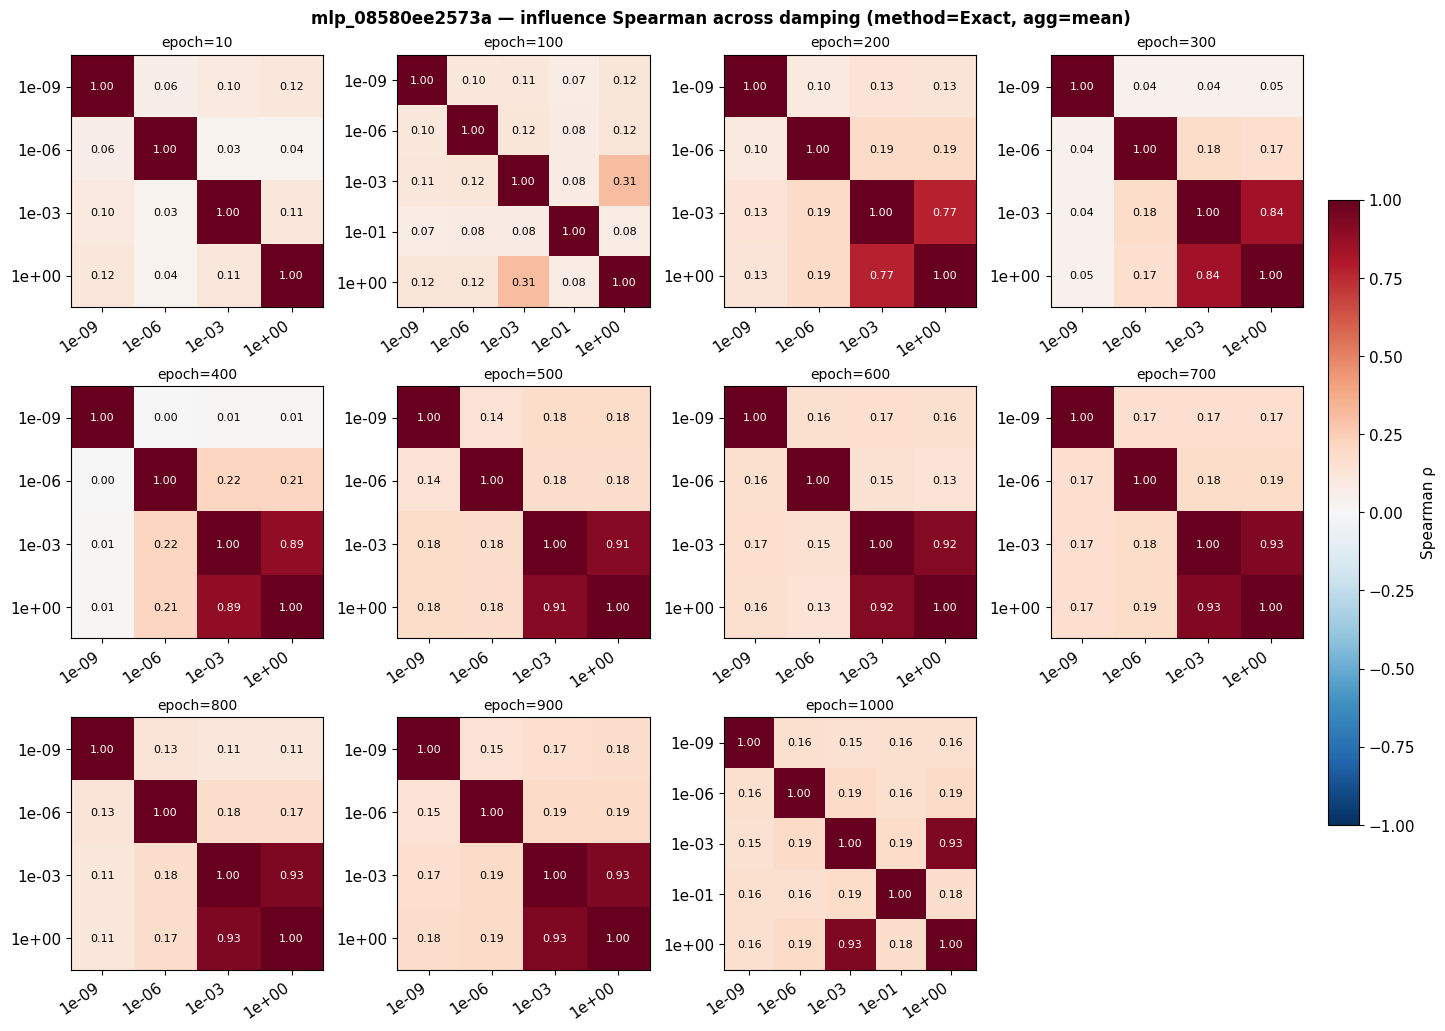

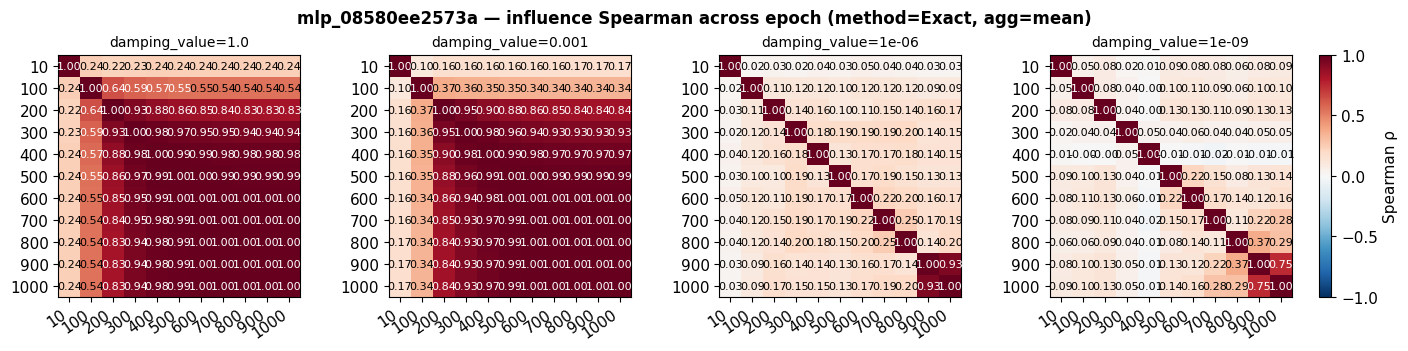

In [25]:
# Heatmap config — edit these to match the sweep you ran.
LAMBDAS = [1.0, 1e-3, 1e-6, 1e-9]
EPOCHS = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
MODEL = "mlp_08580ee2573a"

# A: one panel per epoch, sweep damping within each.
fig = plot_influence_corr_grid(
    df,
    model_id=MODEL,
    sweep="damping",
    fix_values=EPOCHS,
    method="exact",
)
plt.show()

# B: one panel per damping, sweep epoch within each.
fig = plot_influence_corr_grid(
    df,
    model_id=MODEL,
    sweep="epoch",
    fix_values=LAMBDAS,
    method="exact",
)
plt.show()


In [19]:
# Heatmap config — edit these three to match the sweep you ran.
LAMBDAS = [1.0, 1e-3, 1e-6, 1e-9]
EPOCHS = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


for epoch in EPOCHS:
    # A: fix epoch, sweep damping.
    fig, _ = plot_influence_corr_across_axis(
        df,
        model_id=MODEL_ID,
        sweep="damping",
        fix=epoch,
        method="exact",
    )
    plt.show()


In [ ]:
# B: fix damping, sweep epoch.
for lambda_ in LAMBDAS:
    fig, _ = plot_influence_corr_across_axis(
        df,
        model_id=MODEL_ID,
        sweep="epoch",
        fix=lambda_,
        method="exact",
    )
    plt.show()


In [ ]:
# Pairwise Spearman of influence vectors across the swept axis (damping or
# epoch), for a fixed value of the other axis. One method per call.


def plot_influence_corr_across_axis(
    df: pd.DataFrame,
    *,
    model_id: str,
    sweep: str,  # "damping" or "epoch"
    fix,  # value of the OTHER axis
    method: str = "exact",
    aggregate: str = "mean",
    annotate: bool = True,
    db_path: Path = DB_PATH,
):
    """Heatmap of pairwise Spearman across one axis (damping or epoch).

    Each cell (i, j) is the per-query Spearman of `method`'s influence
    matrix between sweep value i and sweep value j (mean / median across
    queries per `aggregate`).
    """
    if sweep not in {"damping", "epoch"}:
        raise ValueError("sweep must be 'damping' or 'epoch'")
    sweep_col = "damping_value" if sweep == "damping" else "epoch"
    fix_col = "epoch" if sweep == "damping" else "damping_value"

    cols = ["run_id", "damping_value", "epoch"]
    grid = df[df["model_id"] == model_id][cols].drop_duplicates()
    rows = grid[grid[fix_col] == fix].sort_values(sweep_col)
    if rows.empty:
        avail = sorted(grid[fix_col].dropna().unique().tolist())
        raise ValueError(
            f"No rows for model_id={model_id} with {fix_col}={fix}. "
            f"Available {fix_col}: {avail}"
        )

    # Load + prepare the chosen method's influence scores at each sweep value.
    prepared: dict = {}
    canonical_shape = None
    with open_db(db_path) as con:
        for _, r in rows.iterrows():
            x = r[sweep_col]
            paths = load_influence_paths(
                con,
                r["run_id"],
                model_id,
                int(r["epoch"]),
            )
            if method not in paths:
                print(f"  skip {sweep}={x}: method {method!r} not in influence paths")
                continue
            arr = _as_2d(np.load(paths[method]).astype(np.float64))
            if canonical_shape is None:
                canonical_shape = arr.shape
            if arr.shape != canonical_shape:
                print(f"  skip {sweep}={x}: shape {arr.shape} != {canonical_shape}")
                continue
            prepared[x] = _row_centered_unit(rankdata(arr, axis=1))

    if len(prepared) < 2:
        raise ValueError(
            f"Need ≥2 sweep points with usable {method!r} influence; got {len(prepared)}"
        )

    xs = sorted(prepared)
    n = len(xs)
    mat = np.full((n, n), np.nan)
    for i, xi in enumerate(xs):
        mat[i, i] = 1.0
        for j in range(i + 1, n):
            rhos = _per_query_spearman_vec(prepared[xi], prepared[xs[j]])
            mat[i, j] = mat[j, i] = _aggregate(rhos, aggregate)

    # Plot.
    fig, ax = plt.subplots(
        figsize=(max(5, 0.7 * n + 3), max(4.5, 0.7 * n + 2)),
        constrained_layout=True,
    )
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)

    if sweep == "damping":
        labels = [f"{x:.0e}" if x != 0 else "0" for x in xs]
    else:
        labels = [str(int(x)) for x in xs]
    ticks = np.arange(n)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_yticklabels(labels)

    if annotate:
        for i in range(n):
            for j in range(n):
                v = mat[i, j]
                if not np.isfinite(v):
                    continue
                color = "white" if abs(v) > 0.55 else "black"
                ax.text(
                    j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=color
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman ρ")

    n_query = canonical_shape[0] if canonical_shape else 0
    summary = (
        f"{n_query} query"
        + ("y" if n_query == 1 else "ies")
        + (" (1D cache)" if n_query == 1 else f", aggregated by {aggregate}")
    )
    ax.set_xlabel(sweep_col.replace("_", " "))
    ax.set_ylabel(sweep_col.replace("_", " "))
    ax.set_title(
        f"{model_id} — influence Spearman across {sweep}\n"
        f"method={LABELS.get(method, method)}, fixed {fix_col}={fix} ({summary})",
        fontsize=11,
        fontweight="bold",
    )
    return fig, pd.DataFrame(mat, index=xs, columns=xs)


# # Example A: fix epoch, sweep damping.
# fig, _ = plot_influence_corr_across_axis(
#     df,
#     model_id=MODEL_ID,
#     sweep="damping",
#     fix=EPOCH,
#     method="exact",
# )
# plt.show()

# Example B: fix damping, sweep epoch (uncomment to use).
fig, _ = plot_influence_corr_across_axis(
    df,
    model_id=MODEL_ID,
    sweep="epoch",
    fix=0.1,
    method="exact",
)
plt.show()


## Factor eigenvalues

Point `plot_factor_eigenvalues` at any `<method>_layer_matrix/` directory under `outputs/models/.../factors/`. It reads the manifest, builds the per-layer eigenvalue spectrum (Kronecker → `Lambda` or `outer(λ_A, λ_G)`; dense → `eigvalsh` of the symmetrised diagonal block), and returns a line plot + a layers×rank heatmap.

In [ ]:
FACTOR_DIR = Path(
    "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/digits/"
    "mlp_08580ee2573a/epoch_100/collector_mcmc_r1_s42/factors/ekfac_layer_matrix"
)
# ekfac_layer_matrix

fig, eigs_by_layer = plot_factor_eigenvalues(FACTOR_DIR)
plt.show()

# eigs_by_layer is dict[layer -> np.ndarray of eigenvalues, sorted descending]
print({l: v.shape for l, v in eigs_by_layer.items()})